# Corpus: Python for Data Science

##Corpus Acquisition and Load

We begin our analysis by loading the raw text that will serve as our corpus. We retrieve the full text of **Python for Data Science** directly from Github and read it into memory as a single string.

We perform a character count and text preview to confirm the corpus has been loaded.

In [15]:
import requests

# Read Python for Data Science text
url = "https://raw.githubusercontent.com/johnnydrodriguez/data620/refs/heads/main/Python_for_Data_Science.txt"
corpus_raw = requests.get(url).text

# Check text load
print(f"Corpus loaded. Total characters: {len(corpus_raw):,}")
print("-" * 30)
print(corpus_raw[101000:101500])

Corpus loaded. Total characters: 939,804
------------------------------
 sec- 
tions; here we'll demonstrate several ways of creating a NumPy array. 




We'll start with the standard NumPy import, under the alias np: 




In[7]: import numpy as np 




38 | Chapter 2: Introduction to NumPy 




Creating Arrays from Python Lists 
First, we can use np.array to create arrays from Python lists: 




In[8]: # integer array: 
np.array([1, 4, 2, 5, 3]) 




Out[8]: array([1, 4, 2, 5, 3]) 
Remember that unlike Python lists, NumPy is constr


## Text Repair and Named Entity Filtering

The raw text contained artifacts that were contaminating the analysis. Interestingly, much of this clean up occured through an iterative, trial-and-error process where subsequent runs of the code surfaced new text issues.  Broadly, we address two distinct problems: formatting issues and semantic noise. First, we repair the text itself; then we use spaCy's Named Entity Recognition (NER) model to filter out tokens that distort our word-frequency analysis.  Proper nouns like people's names, places, and organizations aren't part of the book's *vocabulary* in a meaningful sense for our use case and are removed. The result is a clean list of lowercase, alphabetic tokens stripped of named-entity noise.  

**Preprocessing steps performed:**

- **Line-break hyphen repair** — Rejoins words that were split across lines by a hyphen (e.g., "data - science" corrected to "datascience").
- **Targeted typo correction** — Fixes a recurring artifact where "employee" was split as "emp loyee."
- **spaCy NLP processing** — Runs the `en_core_web_sm` model over the full corpus to perform tokenization, POS tagging, and named entity recognition.
- **Named entity exclusion** — Drops tokens tagged as PERSON, GPE (geopolitical entities), LOC, FAC (facilities), or ORG to remove proper nouns tyhat add noise to our vocabulary frequency analysis.
- **Alpha-only filtering and lowercasing** — Retains only purely alphabetic tokens and normalizes case to ensure "Data" and "data" count as the same word.

In [16]:
import re
import spacy

# Fix line-break hyphens
corpus_repaired = re.sub(r'([a-zA-Z])-\s+([a-zA-Z])', r'\1\2', corpus_raw)

# Fix the specific "emp loyee" text typos
corpus_repaired = re.sub(r'\bemp\s+loyee\b', 'employee', corpus_repaired, flags=re.IGNORECASE)

# 2. Named Entity Recognition (NER) Initialization
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 1500000

# Perform SpaCy tokenization, tagging, and NER
print("Processing NER model...")
doc = nlp(corpus_repaired)

# 3. Entity Filtering and Normalization
tokens_clean = []
dropped_entity_count = 0

# Define entities to exclude
noise_entities = {"PERSON", "GPE", "LOC", "FAC", "ORG"}

for token in doc:
    if token.is_alpha:
        if token.ent_type_ in noise_entities:
            dropped_entity_count += 1
            continue
        tokens_clean.append(token.text.lower())

# 4. Profile Output
print(f"{'Original Raw Length':<35} | {len(corpus_raw):,}")
print(f"{'Entities Removed (NER Filter)':<35} | {dropped_entity_count:,}")
print(f"{'Cleaned Tokens (Alpha, No Names)':<35} | {len(tokens_clean):,}")

Processing NER model...
Original Raw Length                 | 939,804
Entities Removed (NER Filter)       | 5,337
Cleaned Tokens (Alpha, No Names)    | 104,363


## Stop Word Removal, Lemmatization, and Corpus Frequency Profiling

With named entities filtered out, we remove stop words and apply lemmatization.  

Stop words (common function words like "the," "is," "and") carry no topical signal; removing them lets the true subject-matter vocabulary surface.

Lemmatization collapses inflected forms to their base (e.g., "models" > "model", "learning" > "learn") so that variants are counted together rather than adding noise to the frequency distribution.

Note that `tokens_clean` is preserved for the downstream Bigram PMI/collocation analysis;  bigram context depends on natural word order including stop words.

<br>

**Preprocessing steps performed:**

- **Stop word removal** — Filters out NLTK's standard English stop word list.
- **Lemmatization** — Applies WordNet-based lemmatization to reduce each remaining token to its  base form.

**Corpus Results**

- **Tokens (Pre-Stop Words) — 104,363:** After stripping out named entities and non-alphabetic noise,  we start with a corpus of about 104K meaningful word tokens.

- **Tokens (After Stop Words) — 60,437:** Removing stop words cut nearly half the corpus away, leaving ~60K content-bearing tokens that carry topical signal about data science.

- **Stop Word Proportion — 42.09%:** Roughly 42% of the text were words like "the," "is," and "of" ; this is inline with typical English language results.

- **Unique Words (Final Base) — 5,345:** The corpus has 5,345 distinct, alpha, lowercased lemmatized vocabulary entries; this is  focused vocabulary indicative of a technical textbook that reuses its core terminology heavily.

- **Type-Token Ratio (TTR) — 0.0884:** A TTR under 0.09 means the text is highly repetitive in its word choices, likely a reflection of the textbook that hammers home the same concepts across chapters of the book.

- **Hapax Legomena — 2,134 (39.93% of vocabulary):** About 40% of the entire vocabulary consists of words that appear exactly once.  Zipf's law predicts a large hapax proportion; the corpus has along tail of rare terms alongside its dominant core vocabulary.

- **Words for 50% Corpus Volume — 224:** Just 224 words account for half of all 60K tokens in the corpus.

- **Core/Vocabulary Proportion — 4.19%:** The 224 words represent only about 4% of the total vocabulary; a tiny portion of the lexicon does most of the heavy lifting. The other 96% of unique words collectively share the remaining half of the corpus.  This again likely reflects a core set of word in technical textbook supporting a  range of subtopics.

In [17]:
import nltk
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Load nltk resources
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

# 1 Establish baseline token count from spaCy
baseline_token_count = len(tokens_clean)

# 2. Stop Word Removal
stop_words_english = set(stopwords.words('english'))

# Preserve 'tokens_clean' for the downstream PMI analysis
tokens_meaningful = [word for word in tokens_clean if word not in stop_words_english]

# 3. Lemmatization
lemmatizer = WordNetLemmatizer()
tokens_final = [lemmatizer.lemmatize(word) for word in tokens_meaningful]

# 4. Calculations
meaningful_count = len(tokens_meaningful)
final_token_count = len(tokens_final)
unique_final_count = len(set(tokens_final))

# Recalculating metrics based on the NER-filtered baseline
ttr_final = unique_final_count / final_token_count if final_token_count > 0 else 0
stop_word_pct = ((baseline_token_count - meaningful_count) / baseline_token_count) * 100

word_freqs = Counter(tokens_final)
top_15_words = word_freqs.most_common(15)

# Hapax Legomena Calculation
hapax_count = sum(1 for count in word_freqs.values() if count == 1)
hapax_vocab_pct = (hapax_count / unique_final_count) * 100 if unique_final_count > 0 else 0

# Lexical Concentration Calculation
half_corpus_volume = final_token_count / 2

cumulative_sum = 0
words_for_half_volume = 0

# Iterate through the frequency distribution in descending order
for word, freq in word_freqs.most_common():
    cumulative_sum += freq
    words_for_half_volume += 1
    if cumulative_sum >= half_corpus_volume:
        break

# Percentage of the unique  vocabulary this core group represents
core_vocab_pct = (words_for_half_volume / unique_final_count) * 100 if unique_final_count > 0 else 0

# 5. Profile Output
print("-" * 50)
print(f"{'Tokens (Pre-Stop Words)':<30} | {baseline_token_count:,}")
print(f"{'Tokens (After Stop Words)':<30} | {meaningful_count:,}")
print(f"{'Stop Word Proportion':<30} | {stop_word_pct:.2f}%")
print(f"{'Unique Words (Final Base)':<30} | {unique_final_count:,}")
print(f"{'Type-Token Ratio (Final)':<30} | {ttr_final:.4f}")
print("-" * 50)
print(f"{'Hapax Legomena (Count)':<30} | {hapax_count:,}")
print(f"{'Hapax/Vocabulary Proportion':<30} | {hapax_vocab_pct:.2f}%")
print("-" * 50)
# --- NEW: Lexical Concentration Output ---
print(f"{'Words for 50% Corpus Volume':<30} | {words_for_half_volume:,}")
print(f"{'Core/Vocabulary Proportion':<30} | {core_vocab_pct:.2f}%")
print("-" * 50)
print("Top 15 Most Frequent Technical Terms:")
print("-" * 50)
for word, freq in top_15_words:
    print(f"  {word:<28} | {freq:,}")

--------------------------------------------------
Tokens (Pre-Stop Words)        | 104,363
Tokens (After Stop Words)      | 60,437
Stop Word Proportion           | 42.09%
Unique Words (Final Base)      | 5,345
Type-Token Ratio (Final)       | 0.0884
--------------------------------------------------
Hapax Legomena (Count)         | 2,134
Hapax/Vocabulary Proportion    | 39.93%
--------------------------------------------------
Words for 50% Corpus Volume    | 224
Core/Vocabulary Proportion     | 4.19%
--------------------------------------------------
Top 15 Most Frequent Technical Terms:
--------------------------------------------------
  data                         | 1,361
  figure                       | 719
  array                        | 610
  model                        | 560
  example                      | 539
  use                          | 476
  plot                         | 395
  x                            | 383
  function                     | 379
  see            

## Zipf's Law Validation and Top 200 Frequency Decay

**Zipf's Law Validation (Log-Log Scale)**

This plot compares the rank-frequency distribution of the entire processed vocabulary against the theoretical Zipfian baseline (the red dashed line). The empirical curve (blue) bulging above the Zipf line indicates a concentrated technical vocabulary where these terms appear much more frequently than standard natural language predicts.  This is likely a consequence of having stripped out the high-frequency stop words which then artificially inflates the rank of words that would not be commonly used in the English language.

<br>

**Frequency Decay of Top 200 Terms (Linear Scale)**

This plot visualizes the  power-law distribution at the "head" of the processed corpora  mapping raw occurrence against word rank. The steep drop within the first 25 to 50 ranks indicates that a small fraction of the unique dictionary performs the vast majority of the work.


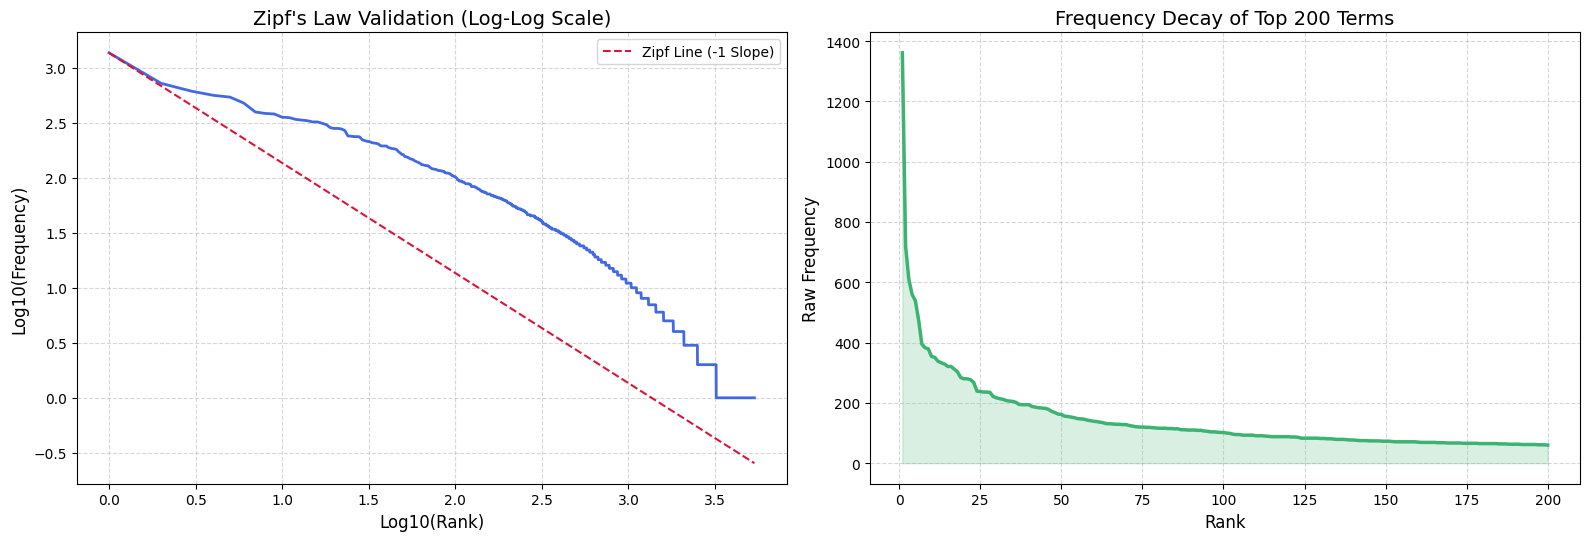

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Zipf's Law Visualization

# Extract frequencies sorted in descending order
all_frequencies = [freq for word, freq in word_freqs.most_common()]
ranks = np.arange(1, len(all_frequencies) + 1)

# Isolate the top 200
top_200_freqs = all_frequencies[:200]
top_200_ranks = ranks[:200]

# Initialize the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-Log Zipf's Law
axes[0].plot(np.log10(ranks), np.log10(all_frequencies), color='royalblue', linewidth=2)
axes[0].set_title("Zipf's Law Validation (Log-Log Scale)", fontsize=14)
axes[0].set_xlabel("Log10(Rank)", fontsize=12)
axes[0].set_ylabel("Log10(Frequency)", fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Add Zipf Line
max_log_freq = np.log10(all_frequencies[0])
axes[0].plot([0, np.log10(len(ranks))], [max_log_freq, max_log_freq - np.log10(len(ranks))],
             color='crimson', linestyle='--', label='Zipf Line (-1 Slope)')
axes[0].legend()

# Linear Rank-Frequency Decay
axes[1].plot(top_200_ranks, top_200_freqs, color='mediumseagreen', linewidth=2.5)
axes[1].fill_between(top_200_ranks, top_200_freqs, color='mediumseagreen', alpha=0.2)
axes[1].set_title("Frequency Decay of Top 200 Terms", fontsize=14)
axes[1].set_xlabel("Rank", fontsize=12)
axes[1].set_ylabel("Raw Frequency", fontsize=12)
axes[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Bigram Collocation Extraction via Likelihood Ratio

We use NLTK's `BigramCollocationFinder` to identify statistically significant two-word collocations which offer more conceptual weight that would otherwise not be detected by unigram analysis. In our case, this process surfaces meaningful pairs like "data science" or "machine learning".  We score the bigrams using likelihood ratio. The Likelihood ratio is preferred over the raw PMI metric because PMI tends to over-promote very rare pairs that co-occur by accident; the likelihood ratio test is more robust to low-frequency noise. The analysis starts from the pre-stop-word token list (`tokens_clean`) because bigram detection depends on natural adjacency. Removing stop words before finding bigrams would artificially create false neighbors.

**Filtering steps performed:**

- **Lemmatization** — Tokens are lemmatized before bigram detection so that variants (e.g., "decision trees" and "decision tree") consolidate into the same bigram.
- **Frequency filter (≥5)** — Discards any bigram occurring fewer than 5 times, eliminating unreliable low-count pairs.
- **Exclusion matrix** — A combined set of stop words, textbook-structural noise ("figure," "chapter," "section"), temporal abbreviations, measurement units, toy dataset names ("setosa," "alice"), and Python syntax keywords are all filtered out to focus on core vocabulary; we use this to eliminate domain specific noise.
- **Minimum word length** — Single-character tokens are excluded to remove residual noise.
- **Targeted n-gram removal** — Specific known-noisy bigrams (e.g., "fig_ax" from matplotlib)  are manually excluded.

**Bigram Results**

The resulting bigrams are highly representative of the core vocabulary and topics in the book and the subject-matter in general. Having read the book and initially evaluated the bigrams using the PMI measure, the Likelihood Ratio measure does a much better job at surfacing the core vocabulary of the book -- and is much more representative than the unigram / single token list.

In [19]:
import nltk
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load nltk resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 1. Lemmazation
lemmatizer = WordNetLemmatizer()
tokens_for_pmi = [lemmatizer.lemmatize(word) for word in tokens_clean]

# 2. Initialize the Bigram Finder
finder = BigramCollocationFinder.from_words(tokens_for_pmi)

# 3. Define the Exclusion Matrix
stop_words_english = set(stopwords.words('english'))

textbook_noise = {'figure', 'chapter', 'section', 'example', 'page', 'shown', 'using', 'see', 'value'}
temporal_noise = {'mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'}
measurement_noise = {'sq', 'mi', 'km', 'cm', 'mm', 'kg', 'lbs'}
toy_data_noise = {'setosa', 'versicolor', 'virginica', 'mary', 'bread', 'bob', 'alice'}
syntax_noise = {'import', 'inline', 'matplotlib', 'numpy', 'pandas', 'false', 'true', 'none', 'def', 'return', 'print'}

# Combine all sets
all_exclusions = stop_words_english.union(textbook_noise, temporal_noise, measurement_noise, toy_data_noise, syntax_noise)

# 4. Apply Multi-Stage Filtering
# Frequency Filter
finder.apply_freq_filter(5)

# Discard solitary character or stop word Bigrams
exclusion_filter = lambda w: len(w) < 2 or w in all_exclusions
finder.apply_word_filter(exclusion_filter)

# Targeted N-Gram Filter
bad_bigrams = {
    ('fig', 'ax'),
    ('per', 'loop')}
ngram_filter = lambda w1, w2: (w1, w2) in bad_bigrams
finder.apply_ngram_filter(ngram_filter)

# 5. Score and Extract Pointwise Mutual Information (PMI)
bigram_measures = BigramAssocMeasures()
top_collocations = finder.nbest(bigram_measures.likelihood_ratio, 25)

# 6. Profile Output
print("-" * 50)
print("Top 25 Extracted Collocations (PMI):")
print("-" * 50)
for w1, w2 in top_collocations:
    print(f"  {w1}_{w2}")

--------------------------------------------------
Top 25 Extracted Collocations (PMI):
--------------------------------------------------
  machine_learning
  two_dimensional
  support_vector
  random_forest
  decision_tree
  linear_regression
  three_dimensional
  dimensionality_reduction
  scikit_learn
  principal_component
  vector_machine
  data_manipulation
  cross_validation
  kernel_density
  density_estimation
  basis_function
  fancy_indexing
  manifold_learning
  time_series
  data_science
  component_analysis
  naive_bayes
  real_world
  multiply_indexed
  handwritten_digit


## Bigram Frequency Distribution and Likelihood Ratio Decay

**Zipf's Law Validation: Bigram Frequencies (Log-Log Scale)**

This plot shows that while bigram frequencies follow a power-law distribution, they decay more gradually than the theoretical Zipfian baseline (the red dashed line). This shallower slope occurs because the vocabulary of multi-word technical concepts is highly concentrated and deliberately reused throughout a textbook.

<br>

**Likelihood Ratio Scores**

This curve visualizes the statistical association strength of word pairings.  It shows  a massive spike for the most tightly related collocations followed by a rapid exponential decay. This confirms that only a very small fraction of bigrams have statistical significance which isolate core concepts from coincidental word pairings in the long tail.

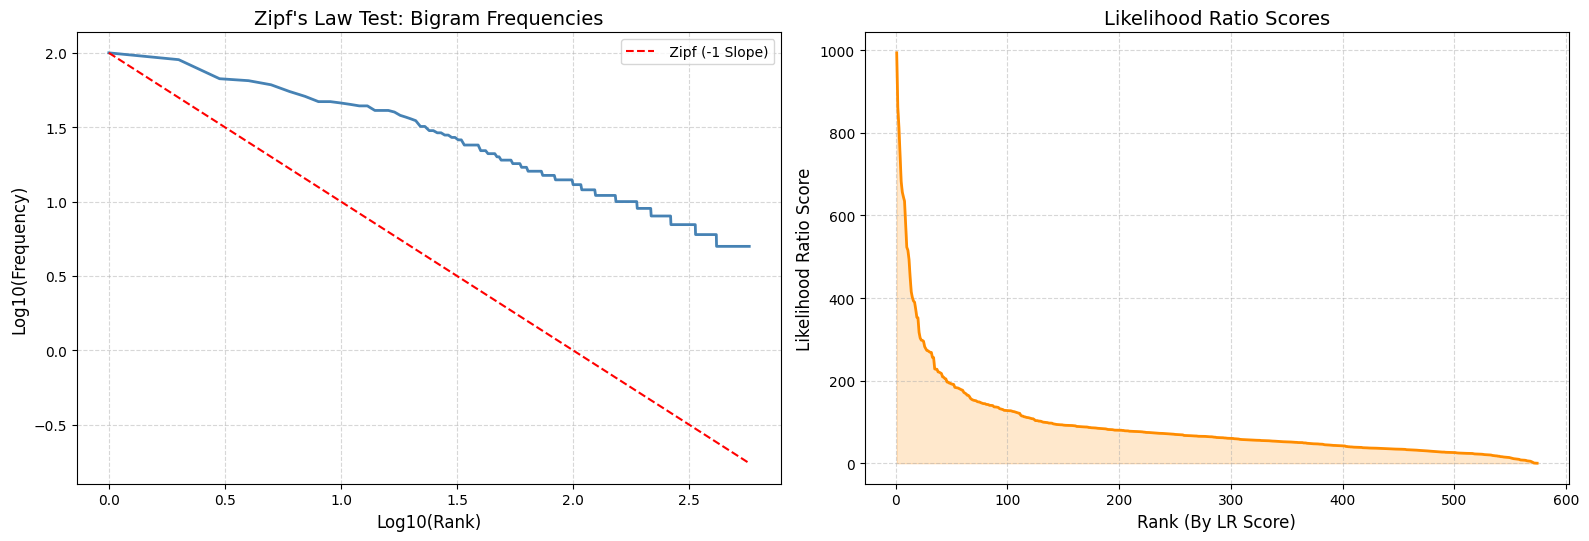

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the Full Distribution
scored_bigrams = finder.score_ngrams(bigram_measures.likelihood_ratio)

# 2. Separate the Data into Vectors
ranks = np.arange(1, len(scored_bigrams) + 1)
lr_scores = np.array([score for bigram, score in scored_bigrams])
frequencies = np.array([finder.ngram_fd[bigram] for bigram, score in scored_bigrams])

# Sort frequencies in descending order
sorted_frequencies = np.sort(frequencies)[::-1]

# 3. Initialize the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Testing Zipf's Law
axes[0].plot(np.log10(ranks), np.log10(sorted_frequencies), color='steelblue', linewidth=2)
axes[0].set_title("Zipf's Law Test: Bigram Frequencies", fontsize=14)
axes[0].set_xlabel("Log10(Rank)", fontsize=12)
axes[0].set_ylabel("Log10(Frequency)", fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Add Zipf line
max_log_freq = np.log10(sorted_frequencies[0])
axes[0].plot([0, np.log10(len(ranks))], [max_log_freq, max_log_freq - np.log10(len(ranks))],
             color='red', linestyle='--', label=' Zipf (-1 Slope)')
axes[0].legend()

# Likelihood Ratio Decay
axes[1].plot(ranks, lr_scores, color='darkorange', linewidth=2)
axes[1].set_title("Likelihood Ratio Scores", fontsize=14)
axes[1].set_xlabel("Rank (By LR Score)", fontsize=12)
axes[1].set_ylabel("Likelihood Ratio Score", fontsize=12)
axes[1].grid(True, ls="--", alpha=0.5)
axes[1].fill_between(ranks, lr_scores, color='darkorange', alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])